In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [165]:
# Read the data into a Pandas DataFrame

input_gen = "/Users/mac/Desktop/ RED/Data Final Project/AGGREGATED_GENERATION_PER_TYPE_GENERATION_202312312300-202412312300.csv"  # Load the Excel file
input_price = "/Users/mac/Desktop/ RED/Data Final Project/GUI_ENERGY_PRICES_202412222300-202412232300.csv"  # Load the Excel file
input_load = "/Users/mac/Desktop/ RED/Data Final Project/GUI_TOTAL_LOAD_DAYAHEAD_202312312300-202412312300.csv"  # Load the Excel file




In [167]:
df_gen= pd.read_csv(input_gen)  
df_price= pd.read_csv(input_price)
df_load= pd.read_csv(input_load)

In [168]:
#df_load.head(50)
#df_price.head(50)

In [171]:

df_gen.head(50)

,MTU (CET/CEST),Area,Production Type,Generation (MW)
0,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Biomass,244.00
1,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Fossil Brown coal/Lignite,0.00
2,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Fossil Coal-derived gas,0.00
3,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Fossil Gas,4552.00
4,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Fossil Hard coal,280.00
5,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Fossil Oil,24.00
6,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Fossil Oil shale,0.00
7,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Fossil Peat,0.00
8,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Geothermal,0.00
9,01/01/2024 00:00:00 - 01/01/2024 00:15:00,BZN|ES,Hydro Pumped Storage,1548.00


In [173]:
# Split the 'MTU (CET/CEST)' column into 'Start Time' and 'End Time'
df_gen[["Start TimeFrame", "End TimeFrame"]] = df_gen["MTU (CET/CEST)"].str.split(" - ", expand=True)

# Remove the 'MTU (CET/CEST)' column
df_gen = df_gen.drop(columns=["MTU (CET/CEST)"])

In [174]:
df_gen

,Area,Production Type,Generation (MW),Start TimeFrame,End TimeFrame
0,BZN|ES,Biomass,244.00,01/01/2024 00:00:00,01/01/2024 00:15:00
1,BZN|ES,Fossil Brown coal/Lignite,0.00,01/01/2024 00:00:00,01/01/2024 00:15:00
2,BZN|ES,Fossil Coal-derived gas,0.00,01/01/2024 00:00:00,01/01/2024 00:15:00
3,BZN|ES,Fossil Gas,4552.00,01/01/2024 00:00:00,01/01/2024 00:15:00
4,BZN|ES,Fossil Hard coal,280.00,01/01/2024 00:00:00,01/01/2024 00:15:00
...,...,...,...,...,...
737851,BZN|ES,Waste,-,31/12/2024 23:45:00,01/01/2025 00:00:00
737852,BZN|ES,Wind Offshore,-,31/12/2024 23:45:00,01/01/2025 00:00:00
737853,BZN|ES,Wind Onshore,-,31/12/2024 23:45:00,01/01/2025 00:00:00
737854,BZN|ES,Other,-,31/12/2024 23:45:00,01/01/2025 00:00:00


In [175]:
# Convert 'Start TimeFrame' and 'End TimeFrame' to datetime
df_gen["Start TimeFrame"] = pd.to_datetime(df_gen["Start TimeFrame"], format="%d/%m/%Y %H:%M:%S")
df_gen["End TimeFrame"] = pd.to_datetime(df_gen["End TimeFrame"], format="%d/%m/%Y %H:%M:%S")


In [176]:
# Convert 'Generation (MW)' column to numeric, forcing errors to NaN if conversion fails
df_gen['Generation (MW)'] = pd.to_numeric(df_gen['Generation (MW)'], errors='coerce')

# Convert 'Start TimeFrame' to the nearest hour (for resampling)
df_gen['DateTime'] = df_gen['Start TimeFrame'].dt.floor('h')

# Group by the hourly intervals and production type, then sum the generation values
df_gen_hourly = df_gen.groupby(['DateTime', 'Production Type'], as_index=False)['Generation (MW)'].sum()

# Display the result
df_gen_hourly.head(48)

,DateTime,Production Type,Generation (MW)
0,2024-01-01 00:00:00,Biomass,988.0
1,2024-01-01 00:00:00,Energy storage,0.0
2,2024-01-01 00:00:00,Fossil Brown coal/Lignite,0.0
3,2024-01-01 00:00:00,Fossil Coal-derived gas,0.0
4,2024-01-01 00:00:00,Fossil Gas,17748.0
5,2024-01-01 00:00:00,Fossil Hard coal,1120.0
6,2024-01-01 00:00:00,Fossil Oil,84.0
7,2024-01-01 00:00:00,Fossil Oil shale,0.0
8,2024-01-01 00:00:00,Fossil Peat,0.0
9,2024-01-01 00:00:00,Geothermal,0.0


In [177]:
# Step 0: Define renewable production types
renewable_types = ['Biomass', 'Hydro Pumped Storage', 'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Other renewable', 'Solar', 'Wind Offshore', 'Wind Onshore']

# Step 1: Group the data by hour and production type, summing the generation
df_gen_hourly = df_gen.groupby(['DateTime', 'Production Type'], as_index=False)['Generation (MW)'].sum()

# Step 2: Create the 'Is Renewable' column in the grouped dataframe
df_gen_hourly['Is Renewable'] = df_gen_hourly['Production Type'].isin(renewable_types)

# Step 3: Calculate total generation per hour
df_gen_hourly['Total Generation (MW)'] = df_gen_hourly.groupby('DateTime')['Generation (MW)'].transform('sum')

# Step 4: Calculate renewable generation per hour
df_gen_hourly['Renewable Generation (MW)'] = df_gen_hourly.apply(
    lambda row: row['Generation (MW)'] if row['Is Renewable'] else 0, axis=1
)

# Step 5: Calculate the share of renewable generation
df_gen_hourly['Hourly Renewable Share (%)'] = (df_gen_hourly['Renewable Generation (MW)'] / df_gen_hourly['Total Generation (MW)']) * 100

# Display the result
df_gen_hourly[['DateTime', 'Production Type', 'Generation (MW)', 'Hourly Renewable Share (%)']].head()


,DateTime,Production Type,Generation (MW),Hourly Renewable Share (%)
0,2024-01-01,Biomass,988.0,1.103516
1,2024-01-01,Energy storage,0.0,0.000000
2,2024-01-01,Fossil Brown coal/Lignite,0.0,0.000000
3,2024-01-01,Fossil Coal-derived gas,0.0,0.000000
4,2024-01-01,Fossil Gas,17748.0,0.000000


In [178]:
import pandas as pd

# Assuming df_gen is already your initial dataframe

# Define renewable production types (adjust based on your dataset)
renewable_types = ['Biomass', 'Energy storage']  # Add other renewable types as needed

# Calculate total generation for each hour
df_total_gen = df_gen.groupby('DateTime', as_index=False)['Generation (MW)'].sum()
df_total_gen.rename(columns={'Generation (MW)': 'Total_Generation'}, inplace=True)

# Calculate renewable generation for each hour
df_renewable_gen = df_gen[df_gen['Production Type'].isin(renewable_types)] \
                    .groupby('DateTime', as_index=False)['Generation (MW)'].sum()
df_renewable_gen.rename(columns={'Generation (MW)': 'Renewable_Generation'}, inplace=True)

# Merge the total generation and renewable generation dataframes on DateTime
df_merged = pd.merge(df_total_gen, df_renewable_gen, on='DateTime', how='left')

# Calculate hourly renewable share as a percentage
df_merged['Hourly Renewable Share (%)'] = (df_merged['Renewable_Generation'] / df_merged['Total_Generation']) * 100

# Fill NaN values in Renewable_Generation (for hours with no renewable generation) with 0
df_merged['Renewable_Generation'] = df_merged['Renewable_Generation'].fillna(0)

# Display the result
df_merged.head(8)


,DateTime,Total_Generation,Renewable_Generation,Hourly Renewable Share (%)
0,2024-01-01 00:00:00,89532.0,988.0,1.103516
1,2024-01-01 01:00:00,87184.0,940.0,1.078179
2,2024-01-01 02:00:00,86460.0,884.0,1.022438
3,2024-01-01 03:00:00,84212.0,856.0,1.016482
4,2024-01-01 04:00:00,81780.0,876.0,1.071167
5,2024-01-01 05:00:00,81660.0,848.0,1.038452
6,2024-01-01 06:00:00,82008.0,856.0,1.043801
7,2024-01-01 07:00:00,83688.0,868.0,1.037186


In [180]:
# Step 1: Extract the year, month, and day from the 'DateTime' column
df_gen_hourly['YearDay'] = df_gen_hourly['DateTime'].dt.to_period('D')  # Year-Day format

# Step 2: Group by 'YearDay' and calculate the total generation and renewable generation for each day
df_daily = df_gen_hourly.groupby('YearDay', as_index=False).agg(
    Total_Generation=('Generation (MW)', 'sum'),
    Renewable_Generation=('Renewable Generation (MW)', 'sum')
)

# Step 3: Calculate the daily renewable share
df_daily['Daily Renewable Share (%)'] = (df_daily['Renewable_Generation'] / df_daily['Total_Generation']) * 100

# Display the result for the daily renewable share
df_daily[['YearDay', 'Total_Generation', 'Renewable_Generation', 'Daily Renewable Share (%)']]


,YearDay,Total_Generation,Renewable_Generation,Daily Renewable Share (%)
0,2024-01-01,2356316.0,1261224.0,53.525249
1,2024-01-02,2843316.0,1796408.0,63.180033
2,2024-01-03,2835460.0,1742224.0,61.444140
3,2024-01-04,2512940.0,1314548.0,52.311157
4,2024-01-05,2944080.0,1875980.0,63.720415
...,...,...,...,...
361,2024-12-27,0.0,0.0,NaN
362,2024-12-28,0.0,0.0,NaN
363,2024-12-29,0.0,0.0,NaN
364,2024-12-30,0.0,0.0,NaN


In [182]:
# Step 1: Extract the year and month from the 'DateTime' column
df_gen_hourly['YearMonth'] = df_gen_hourly['DateTime'].dt.to_period('M')  # Year-Month format

# Step 2: Group by 'YearMonth' and calculate the total generation and renewable generation for each month
df_monthly = df_gen_hourly.groupby('YearMonth', as_index=False).agg(
    Total_Generation=('Generation (MW)', 'sum'),
    Renewable_Generation=('Renewable Generation (MW)', 'sum')
)

# Step 3: Calculate the monthly renewable share
df_monthly['Monthly Renewable Share (%)'] = (df_monthly['Renewable_Generation'] / df_monthly['Total_Generation']) * 100

# Display the result for the monthly renewable share
df_monthly[['YearMonth', 'Total_Generation', 'Renewable_Generation', 'Monthly Renewable Share (%)']]


,YearMonth,Total_Generation,Renewable_Generation,Monthly Renewable Share (%)
0,2024-01,88212476.0,49094032.0,55.654295
1,2024-02,83253448.0,52708480.0,63.310867
2,2024-03,84349892.0,58343196.0,69.168074
3,2024-04,79156240.0,54415748.0,68.744736
4,2024-05,80714000.0,54507804.0,67.532032
5,2024-06,81115692.0,50824960.0,62.657371
6,2024-07,91724536.0,53899504.0,58.762362
7,2024-08,87824792.0,49008524.0,55.802608
8,2024-09,81411740.0,45710196.0,56.146934
9,2024-10,81303780.0,47656948.0,58.615907


In [183]:
# Step 1: Extract the year from the 'DateTime' column
df_gen_hourly['Year'] = df_gen_hourly['DateTime'].dt.year

# Step 2: Group by 'Year' and calculate the total generation and renewable generation for each year
df_yearly = df_gen_hourly.groupby('Year', as_index=False).agg(
    Total_Generation=('Generation (MW)', 'sum'),
    Renewable_Generation=('Renewable Generation (MW)', 'sum')
)

# Step 3: Calculate the yearly renewable share
df_yearly['Yearly Renewable Share (%)'] = (df_yearly['Renewable_Generation'] / df_yearly['Total_Generation']) * 100

# Display the result for the yearly renewable share
df_yearly[['Year', 'Total_Generation', 'Renewable_Generation', 'Yearly Renewable Share (%)']]


,Year,Total_Generation,Renewable_Generation,Yearly Renewable Share (%)
0,2024,978233396.0,590191260.0,60.332357


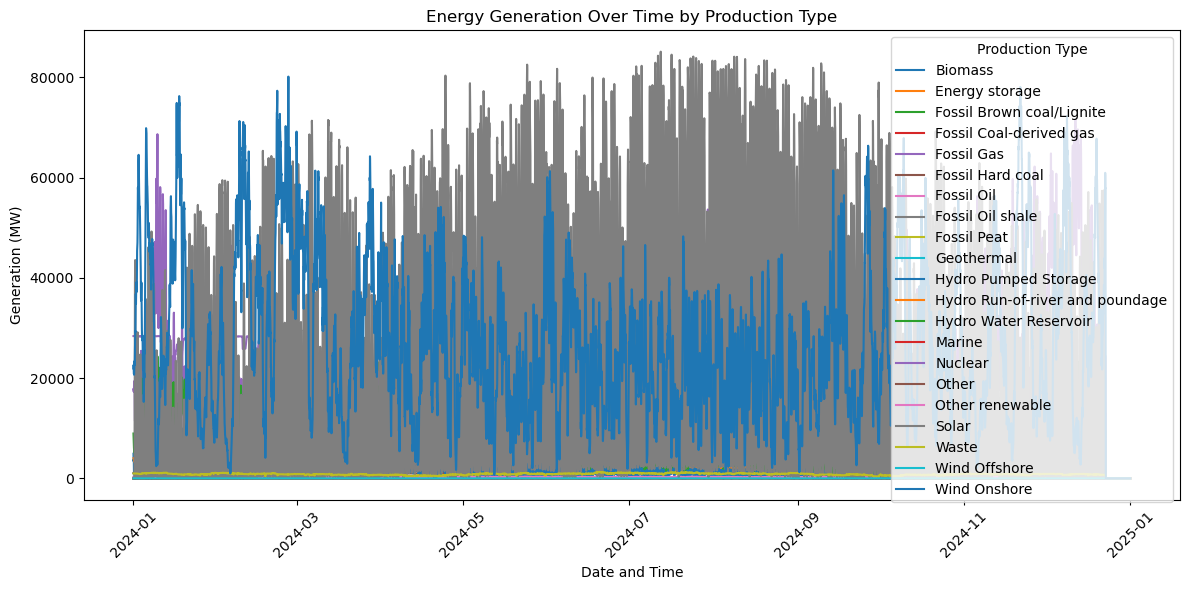

In [186]:
# Plotting the time-series for each production type
plt.figure(figsize=(12, 6))

# Iterate through each unique production type
for production_type in df_gen_hourly['Production Type'].unique():
    # Filter the data for the current production type
    production_data = df_gen_hourly[df_gen_hourly['Production Type'] == production_type]
    
    # Plot the generation data for the current production type
    plt.plot(production_data['DateTime'], production_data['Generation (MW)'], label=production_type)

# Adding labels and title
plt.xlabel('Date and Time')
plt.ylabel('Generation (MW)')
plt.title('Energy Generation Over Time by Production Type')
plt.legend(title='Production Type')

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()

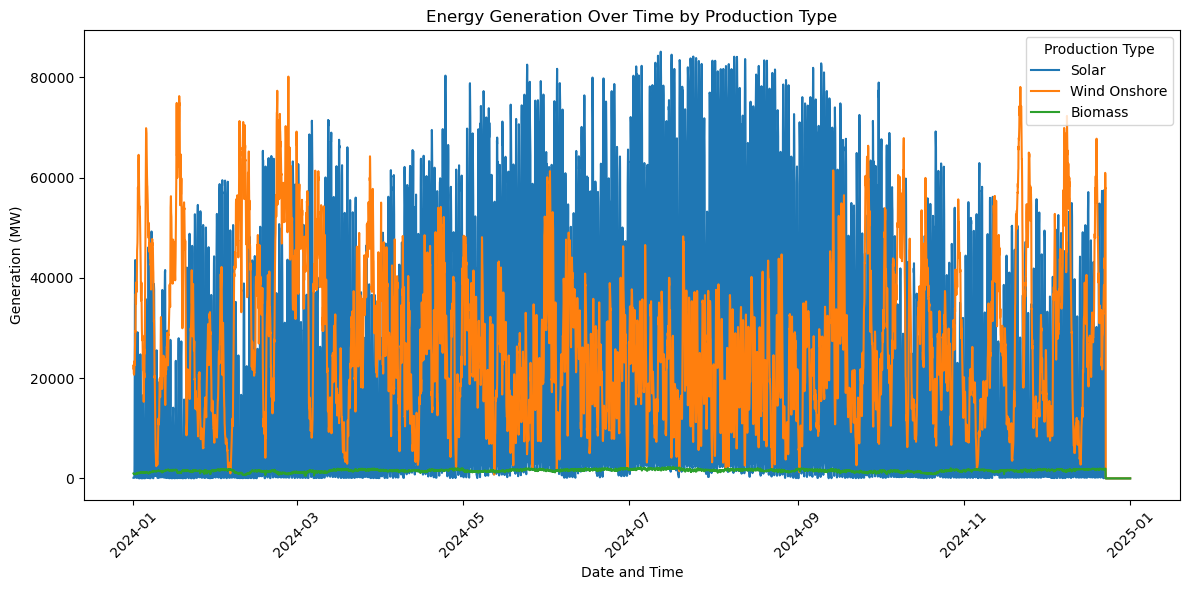

In [187]:

def plot_generation_by_type(df_gen_hourly, selected_types=None):
    """
    Plots energy generation over time for selected production types.

    :param df_gen_hourly: DataFrame containing the generation data
    :param selected_types: List of selected production types to plot. If None, all types are plotted.
    """
    plt.figure(figsize=(12, 6))

    # If no specific types are selected, use all unique production types
    if selected_types is None:
        selected_types = df_gen_hourly['Production Type'].unique()

    # Iterate through each selected production type
    for production_type in selected_types:
        # Filter the data for the current production type
        production_data = df_gen_hourly[df_gen_hourly['Production Type'] == production_type]
        
        # Plot the generation data for the current production type
        plt.plot(production_data['DateTime'], production_data['Generation (MW)'], label=production_type)

    # Adding labels and title
    plt.xlabel('Date and Time')
    plt.ylabel('Generation (MW)')
    plt.title('Energy Generation Over Time by Production Type')
    plt.legend(title='Production Type')

    # Rotate the x-axis labels for better readability
    plt.xticks(rotation=45)

    # Display the plot
    plt.tight_layout()
    plt.show()

# Example: Call the function to plot selected types
# For example, you can pass a list like this:
selected_generation_types = ['Solar', 'Wind Onshore', 'Biomass']
plot_generation_by_type(df_gen_hourly, selected_types=selected_generation_types)

# If you want to plot all types, simply call:
# plot_generation_by_type(df_gen_hourly)


<Figure size 1200x600 with 0 Axes>

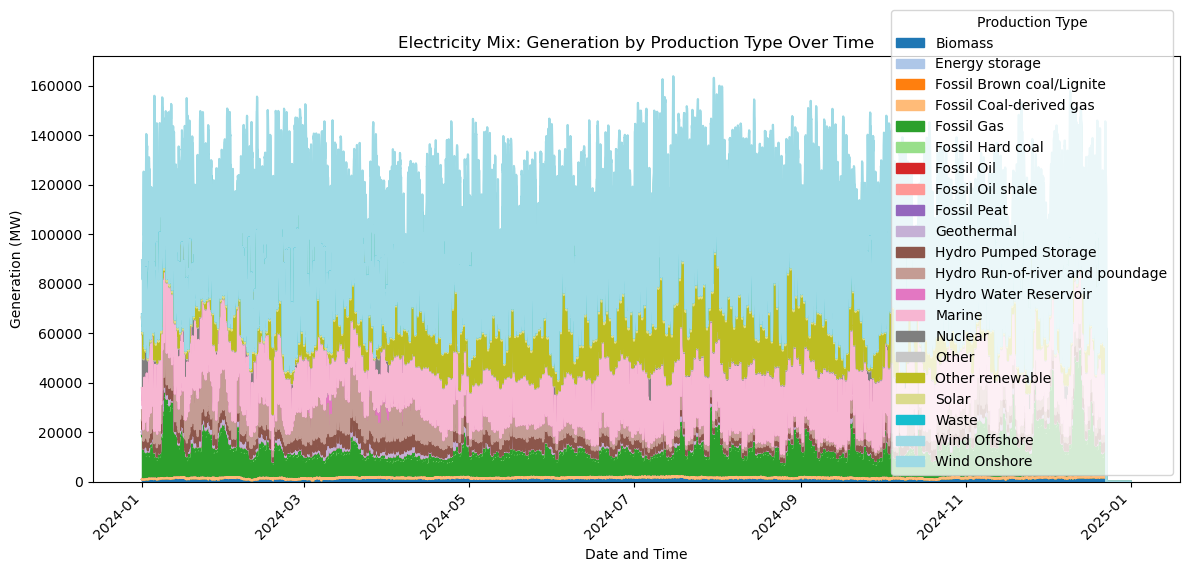

In [188]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure data is properly grouped by hour and production type
df_gen_hourly = df_gen.groupby(['DateTime', 'Production Type'], as_index=False)['Generation (MW)'].sum()

# Pivot the dataframe to create a matrix of production types and their respective generation values
df_gen_pivot = df_gen_hourly.pivot(index='DateTime', columns='Production Type', values='Generation (MW)')

# Fill NaN values with 0 for cases where a production type does not generate at a certain time
df_gen_pivot = df_gen_pivot.fillna(0)

# Plotting the stacked area chart
plt.figure(figsize=(12, 6))

# Plot the stacked area chart, each production type will be stacked on top of others
df_gen_pivot.plot(kind='area', stacked=True, figsize=(12, 6), colormap='tab20')

# Adding labels and title
plt.xlabel('Date and Time')
plt.ylabel('Generation (MW)')
plt.title('Electricity Mix: Generation by Production Type Over Time')

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()


In [190]:
df_price

,MTU (CET/CEST),Area,Sequence,Day-ahead (EUR/MWh),Intraday Period (CET/CEST),Energy Price (EUR/MWh)
0,23/12/2024 00:00:00 - 23/12/2024 01:00:00,BZN|ES,Without sequence,17.27,NaN,NaN
1,23/12/2024 01:00:00 - 23/12/2024 02:00:00,BZN|ES,Without sequence,11.48,NaN,NaN
2,23/12/2024 02:00:00 - 23/12/2024 03:00:00,BZN|ES,Without sequence,10.19,NaN,NaN
3,23/12/2024 03:00:00 - 23/12/2024 04:00:00,BZN|ES,Without sequence,7.33,NaN,NaN
4,23/12/2024 04:00:00 - 23/12/2024 05:00:00,BZN|ES,Without sequence,6.00,NaN,NaN
5,23/12/2024 05:00:00 - 23/12/2024 06:00:00,BZN|ES,Without sequence,7.07,NaN,NaN
6,23/12/2024 06:00:00 - 23/12/2024 07:00:00,BZN|ES,Without sequence,25.95,NaN,NaN
7,23/12/2024 07:00:00 - 23/12/2024 08:00:00,BZN|ES,Without sequence,61.20,NaN,NaN
8,23/12/2024 08:00:00 - 23/12/2024 09:00:00,BZN|ES,Without sequence,72.47,NaN,NaN
9,23/12/2024 09:00:00 - 23/12/2024 10:00:00,BZN|ES,Without sequence,70.93,NaN,NaN


In [199]:
# Split the 'MTU (CET/CEST)' column into 'Start Time' and 'End Time'
df_price[["Start TimeFrame", "End TimeFrame"]] = df_price["MTU (CET/CEST)"].str.split(" - ", expand=True)



In [205]:
# Correct format string to match the period separator
df_price["DateTime"] = pd.to_datetime(df_price["Start TimeFrame"], format="%d/%m/%Y %H:%M:%S")
df_price["End TimeFrame"] = pd.to_datetime(df_price["End TimeFrame"], format="%d/%m/%Y %H:%M:%S")


df_price["DateTime"] = pd.to_datetime(df_price["Start TimeFrame"], errors='coerce', dayfirst=True)
df_price["End TimeFrame"] = pd.to_datetime(df_price["End TimeFrame"], errors='coerce', dayfirst=True)




In [207]:
df_price

,MTU (CET/CEST),Area,Sequence,Day-ahead (EUR/MWh),Intraday Period (CET/CEST),Energy Price (EUR/MWh),Start TimeFrame,End TimeFrame,DateTime
0,23/12/2024 00:00:00 - 23/12/2024 01:00:00,BZN|ES,Without sequence,17.27,NaN,NaN,23/12/2024 00:00:00,2024-12-23 01:00:00,2024-12-23 00:00:00
1,23/12/2024 01:00:00 - 23/12/2024 02:00:00,BZN|ES,Without sequence,11.48,NaN,NaN,23/12/2024 01:00:00,2024-12-23 02:00:00,2024-12-23 01:00:00
2,23/12/2024 02:00:00 - 23/12/2024 03:00:00,BZN|ES,Without sequence,10.19,NaN,NaN,23/12/2024 02:00:00,2024-12-23 03:00:00,2024-12-23 02:00:00
3,23/12/2024 03:00:00 - 23/12/2024 04:00:00,BZN|ES,Without sequence,7.33,NaN,NaN,23/12/2024 03:00:00,2024-12-23 04:00:00,2024-12-23 03:00:00
4,23/12/2024 04:00:00 - 23/12/2024 05:00:00,BZN|ES,Without sequence,6.00,NaN,NaN,23/12/2024 04:00:00,2024-12-23 05:00:00,2024-12-23 04:00:00
5,23/12/2024 05:00:00 - 23/12/2024 06:00:00,BZN|ES,Without sequence,7.07,NaN,NaN,23/12/2024 05:00:00,2024-12-23 06:00:00,2024-12-23 05:00:00
6,23/12/2024 06:00:00 - 23/12/2024 07:00:00,BZN|ES,Without sequence,25.95,NaN,NaN,23/12/2024 06:00:00,2024-12-23 07:00:00,2024-12-23 06:00:00
7,23/12/2024 07:00:00 - 23/12/2024 08:00:00,BZN|ES,Without sequence,61.20,NaN,NaN,23/12/2024 07:00:00,2024-12-23 08:00:00,2024-12-23 07:00:00
8,23/12/2024 08:00:00 - 23/12/2024 09:00:00,BZN|ES,Without sequence,72.47,NaN,NaN,23/12/2024 08:00:00,2024-12-23 09:00:00,2024-12-23 08:00:00
9,23/12/2024 09:00:00 - 23/12/2024 10:00:00,BZN|ES,Without sequence,70.93,NaN,NaN,23/12/2024 09:00:00,2024-12-23 10:00:00,2024-12-23 09:00:00


In [209]:
# Convert 'Generation (MW)' column to numeric, forcing errors to NaN if conversion fails
df_gen['Generation (MW)'] = pd.to_numeric(df_gen['Day-ahead Total Load Forecast [MW] - BZN|ES'], errors='coerce')

# Convert 'Start TimeFrame' to the nearest hour (for resampling)
df_gen['DateTime'] = df_gen['Start TimeFrame'].dt.floor('h')

# Group by the hourly intervals and production type, then sum the generation values
df_gen_hourly = df_gen.groupby(['DateTime', 'Production Type'], as_index=False)['Generation (MW)'].sum()

# Display the result
df_gen_hourly.head(48)

KeyError: 'Day-ahead Total Load Forecast [MW] - BZN|ES'

In [ ]:


# Step 3: Plotting
fig, ax1 = plt.subplots(figsize=(14, 8))

''' # Plot total generation on the primary axis
ax1.plot(df_merged['DateTime'], df_merged['Total_Generation'], label='Total_Generation (MW)', color='blue', alpha=0.7)
ax1.set_xlabel('Date and Time')
ax1.set_ylabel('Total Generation (MW)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue') 
'''
# Plot hourly renewable share on the primary axis
ax1.plot(df_merged['DateTime'], df_merged['Hourly Renewable Share (%)'], label='Renewable Share (%)', color='green', linestyle='--', alpha=0.7)

# Secondary axis for day-ahead price
ax2 = ax1.twinx()
ax2.plot(df_price['DateTime'], df_price['Day-ahead (EUR/MWh)'], label='Day-ahead Price (EUR/MWh)', color='red', alpha=0.7)
ax2.set_ylabel('Day-ahead Price (EUR/MWh)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Adding legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

# Title and layout adjustments
plt.title('Hourly Energy Mix and Day-ahead Price')
plt.xticks(rotation=45)
plt.tight_layout()

# Show plot
plt.show()


In [ ]:
import requests
import pandas as pd

# Define the endpoint and parameters
url = "https://web-api.entsoe.eu/api"
params = {
    "documentType": "A44",  # Energy prices document type
    "securityToken": "your_api_key_here",  # Your ENTSO-E API key
    "bzn": "10YES-REE------0",  # Price zone, modify as needed
    "startDate": "20240101",  # Start date (January 1, 2024)
    "endDate": "20241231",  # End date (December 31, 2024)
    "period": "PT1H",  # Data frequency (e.g., 1-hour intervals)
    "type": "price",  # Energy price data
}

# Make the request to the ENTSO-E API
response = requests.get(url, params=params)

# Check if the request was successful
if response.status_code == 200:
    # Process the response and extract data
    data = response.json()
    df = pd.DataFrame(data['timeseries'])
    
    # Convert to pandas DataFrame and handle the data
    df['DateTime'] = pd.to_datetime(df['DateTime'], format='%Y-%m-%dT%H:%M:%S')
    df['Price'] = pd.to_numeric(df['Price'])
    
    # Display the data
    print(df.head())
else:
    print(f"Failed to retrieve data: {response.status_code}")
